In [225]:
# We import pandas into Python
import pandas as pd

# We read in a stock data data file into a data frame and see what it looks like
df = pd.read_csv('data/GOOG.csv')

# We display the first 5 rows of the DataFrame
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.676899,51.693783,47.669952,49.845802,49.845802,44994500
1,2004-08-20,50.178635,54.187561,49.925285,53.805050,53.805050,23005800
2,2004-08-23,55.017166,56.373344,54.172661,54.346527,54.346527,18393200
3,2004-08-24,55.260582,55.439419,51.450363,52.096165,52.096165,15361800
4,2004-08-25,52.140873,53.651051,51.604362,52.657513,52.657513,9257400


We clearly see that the Dataframe is has automatically labeled the row indices using integers and has labeled the columns of the DataFrame using the names of the columns in the CSV files.

# To Do

You will now load the stock data from Google, Apple, and Amazon into separte DataFrames. However, for each stock data you will only be interested in loading the `Date` and `Adj Close` columns into the Dataframe. In addtion, you want to use the `Date` column as your row index. Finally, you want the DataFrame to recognize the dates as actual dates (year/month/day) and not as strings. For each stock, you can accomplish all theses things in just one line of code by using the appropiate keywords in the `pd.read_csv()` function. Here are a few hints:

* Use the `index_col` keyword to indicate which column you want to use as an index. For example `index_col = ['Open']`

* Set the `parse_dates` keyword equal to `True` to convert the Dates into real dates of the form year/month/day

* Use the `usecols` keyword to select which columns you want to load into the DataFrame. For example `usecols = ['Open', 'High']`

Fill in the code below:

In [226]:
# We load the Google stock data into a DataFrame
google_stock = pd.read_csv('data/GOOG.csv' , index_col = ["Date"]   , usecols = ["Date", "Adj Close"],parse_dates = ['Date'])
# We load the Apple stock data into a DataFrame
apple_stock = pd.read_csv('data/AAPL.csv' , index_col = ["Date"] ,  usecols = ["Date", "Adj Close"],parse_dates = ['Date'])

# We load the Amazon stock data into a DataFrame
amazon_stock = pd.read_csv('data/AMZN.csv' , index_col = ["Date"] ,  usecols = ["Date", "Adj Close"],parse_dates = ['Date'])


You can check that you have loaded the data correctly by displaying the head of the DataFrames.

In [227]:
# We display the google_stock DataFrame
google_stock.head()

,Adj Close
Date,
2004-08-19,49.845802
2004-08-20,53.805050
2004-08-23,54.346527
2004-08-24,52.096165
2004-08-25,52.657513


You will now join the three DataFrames above to create a single new DataFrame that contains all the `Adj Close` for all the stocks. Let's start by creating an empty DataFrame that has as row indices calendar days between `2000-01-01`  and `2016-12-31`. We will use the `pd.date_range()` function to create the calendar dates first and then we will create a DataFrame that uses those dates as row indices:

In [228]:
# We create calendar dates between '2000-01-01' and  '2016-12-31'
dates = pd.date_range('2000-01-01', '2016-12-31')

# We create and empty DataFrame that uses the above dates as indices
all_stocks = pd.DataFrame(index = dates)

# To Do

You will now join the the individual DataFrames, `google_stock`, `apple_stock`, and `amazon_stock`, to the `all_stocks` DataFrame. However, before you do this, it is necessary that you change the name of the columns in each of the three dataframes. This is because the column labels in the `all_stocks` dataframe must be unique. Since all the columns in the individual dataframes have the same name, `Adj Close`, we must change them to the stock name before joining them. In the space below change the column label `Adj Close` of each individual dataframe to the name of the corresponding stock. You can do this by using the `pd.DataFrame.rename()` function. 

In [229]:
# Change the Adj Close column label to Google
google_stock = google_stock.rename(index = str , columns = {"Adj Close": "Google"})

# Change the Adj Close column label to Apple
apple_stock = apple_stock.rename(index = str , columns = {"Adj Close": "Apple"})

# Change the Adj Close column label to Amazon
amazon_stock = amazon_stock.rename(index = str , columns = {"Adj Close": "Amazon"})

You can check that the column labels have been changed correctly by displaying the datadrames

In [230]:
# We display the google_stock DataFrame
google_stock.head()

,Google
Date,
2004-08-19 00:00:00,49.845802
2004-08-20 00:00:00,53.805050
2004-08-23 00:00:00,54.346527
2004-08-24 00:00:00,52.096165
2004-08-25 00:00:00,52.657513


Now that we have unique column labels, we can join the individual DataFrames to the `all_stocks` DataFrame. For this we will use the `dataframe.join()` function. The function `dataframe1.join(dataframe2)` joins `dataframe1` with `dataframe2`. We will join each dataframe one by one to the `all_stocks` dataframe. Fill in the code below to join the dataframes, the first join has been made for you:

In [231]:
all_stocks = pd.concat([all_stocks, apple_stock.rename(columns={"Adj Close": "Apple"}), amazon_stock.rename(columns={"Adj Close": "Amazon"}), google_stock.rename(columns={"Adj Close":"Google"})], axis=1)

You can check that the dataframes have been joined correctly by displaying the `all_stocks`  dataframe

In [232]:
# We display the google_stock DataFrame
all_stocks

,Apple,Amazon,Google
2000-01-01 00:00:00,NaN,NaN,NaN
2000-01-02 00:00:00,NaN,NaN,NaN
2000-01-03 00:00:00,NaN,NaN,NaN
2000-01-04 00:00:00,NaN,NaN,NaN
2000-01-05 00:00:00,NaN,NaN,NaN
...,...,...,...
2017-10-09 00:00:00,155.839996,990.989990,977.000000
2017-10-10 00:00:00,155.899994,987.200012,972.599976
2017-10-11 00:00:00,156.550003,995.000000,989.250000
2017-10-12 00:00:00,156.000000,1000.929993,987.830017


# To Do

Before we proceed to get some statistics on the stock data, let's first check that we don't have any *NaN* values. In the space below check if there are any *NaN* values in the `all_stocks`  dataframe. If there are any, remove any rows that have *NaN* values:

In [233]:
# Check if there are any NaN values in the all_stocks dataframe
all_stocks.isnull().values.any()
# Remove any rows that contain NaN values
all_stocks = all_stocks.dropna()

Now that you have eliminated any *NaN* values we can now calculate some basic statistics on the stock prices. Fill in the code below

In [234]:
# Print the average stock price for each stock
print(all_stocks.mean(axis = 0))
# Print the median stock price for each stock
print(all_stocks.median(axis = 0))
# Print the standard deviation of the stock price for each stock  
print(all_stocks.std(axis = 0))
# Print the correlation between stocks
print(all_stocks.corr)


Apple      53.535194
Amazon    259.044320
Google    380.072458
dtype: float64
Apple      43.554916
Amazon    179.460007
Google    293.029114
dtype: float64
Apple      43.068747
Amazon    256.779834
Google    223.853780
dtype: float64
<bound method DataFrame.corr of                           Apple       Amazon      Google
2004-08-19 00:00:00    1.973460    38.630001   49.845802
2004-08-20 00:00:00    1.979244    39.509998   53.805050
2004-08-23 00:00:00    1.997236    39.450001   54.346527
2004-08-24 00:00:00    2.053144    39.049999   52.096165
2004-08-25 00:00:00    2.123831    40.299999   52.657513
...                         ...          ...         ...
2017-10-09 00:00:00  155.839996   990.989990  977.000000
2017-10-10 00:00:00  155.899994   987.200012  972.599976
2017-10-11 00:00:00  156.550003   995.000000  989.250000
2017-10-12 00:00:00  156.000000  1000.929993  987.830017
2017-10-13 00:00:00  156.990005  1002.940002  989.679993

[3313 rows x 3 columns]>


We will now look at how we can compute some rolling statistics, also known as moving statistics. We can calculate for example the rolling mean (moving average) of the Google stock price by using the Pandas `dataframe.rolling().mean()` method. The `dataframe.rolling(N).mean()` calculates the rolling mean over an `N`-day window. In other words, we can take a look at the average stock price every `N`  days using the above method. Fill in the code below to calculate the average stock price every 150 days for Google stock

In [235]:
# We compute the rolling mean using a 150-Day window for Google stock
rollingMean = all_stocks['Google'].rolling(150).mean()
print(all_stocks)


                          Apple       Amazon      Google
2004-08-19 00:00:00    1.973460    38.630001   49.845802
2004-08-20 00:00:00    1.979244    39.509998   53.805050
2004-08-23 00:00:00    1.997236    39.450001   54.346527
2004-08-24 00:00:00    2.053144    39.049999   52.096165
2004-08-25 00:00:00    2.123831    40.299999   52.657513
...                         ...          ...         ...
2017-10-09 00:00:00  155.839996   990.989990  977.000000
2017-10-10 00:00:00  155.899994   987.200012  972.599976
2017-10-11 00:00:00  156.550003   995.000000  989.250000
2017-10-12 00:00:00  156.000000  1000.929993  987.830017
2017-10-13 00:00:00  156.990005  1002.940002  989.679993

[3313 rows x 3 columns]


We can also visualize the rolling mean by plotting the data in our dataframe. In the following lessons you will learn how to use **Matplotlib** to visualize data. For now I will just import matplotlib and plot the Google stock data on top of the rolling mean. You can play around by changing the rolling mean window and see how the plot changes. 

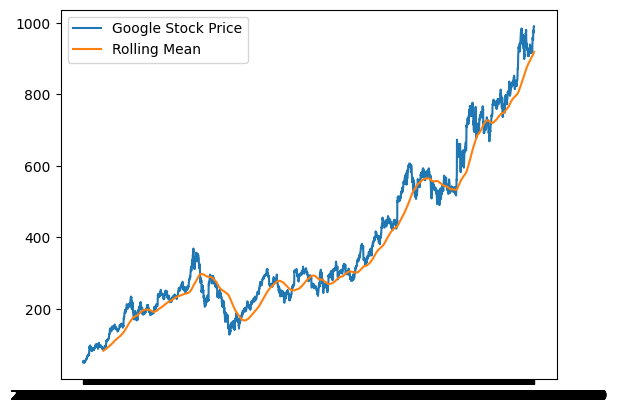

In [236]:
# this allows plots to be rendered in the notebook
%matplotlib inline 

# We import matplotlib into Python
import matplotlib.pyplot as plt


# We plot the Google stock data
plt.plot(all_stocks['Google'])

# We plot the rolling mean ontop of our Google stock data
plt.plot(rollingMean)
plt.legend(['Google Stock Price', 'Rolling Mean'])
plt.show()